## conda install

In [1]:
!conda install -c conda-forge xgboost=3.0.2 lightgbm=4.6.0 missingno=0.5.2 -y

Channels:
 - conda-forge
Platform: linux-64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 25.5.1
    latest version: 26.5.2

Please update conda by running

    $ conda update -n base -c conda-forge conda



## Package Plan ##

  environment location: /opt/conda

  added / updated specs:
    - lightgbm=4.6.0
    - missingno=0.5.2
    - xgboost=3.0.2


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    ca-certificates-2026.5.20  |       hbd8a1cb_0         127 KB  conda-forge
    certifi-2026.5.20          |     pyhd8ed1ab_0         131 KB  conda-forge
    libboost-1.90.0            |       hed09d94_0         3.1 MB  conda-forge
    liblightgbm-4.6.0          |   cpu_hf025404_8         3.3 MB  conda-forge
    libxgboost-3.0.2           |   cpu_h2ebb00f_1         3.3 MB  conda-forge
    lightgbm-4.6.0             |cpu_py_hb6b7976_8          

## 시작

In [2]:
import warnings
warnings.filterwarnings("ignore")

import os
from os.path import join

import pandas as pd
import numpy as np

import missingno as msno

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import KFold, cross_val_score
import xgboost as xgb
import lightgbm as lgb

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
train_data_path = join('./data', 'train.csv')
test_data_path = join('./data', 'test.csv')

## 1. 데이터 살펴보기
pandas의 read_csv 함수를 사용해 데이터를 읽어오고, 각 변수들이 나타내는 의미를 살펴보겠습니다.
1. ID : 집을 구분하는 번호
2. date : 집을 구매한 날짜
3. price : 타겟 변수인 집의 가격
4. bedrooms : 침실의 수
5. bathrooms : 침실당 화장실 개수
6. sqft_living : 주거 공간의 평방 피트
7. sqft_lot : 부지의 평방 피트
8. floors : 집의 층 수
9. waterfront : 집의 전방에 강이 흐르는지 유무 (a.k.a. 리버뷰)
10. view : 집이 얼마나 좋아 보이는지의 정도
11. condition : 집의 전반적인 상태
12. grade : King County grading 시스템 기준으로 매긴 집의 등급
13. sqft_above : 지하실을 제외한 평방 피트
14. sqft_basement : 지하실의 평방 피트
15. yr_built : 집을 지은 년도
16. yr_renovated : 집을 재건축한 년도
17. zipcode : 우편번호
18. lat : 위도
19. long : 경도
20. sqft_living15 : 2015년 기준 주거 공간의 평방 피트(집을 재건축했다면, 변화가 있을 수 있음)
21. sqft_lot15 : 2015년 기준 부지의 평방 피트(집을 재건축했다면, 변화가 있을 수 있음)

In [4]:
import pandas as pd
data_dir = './data'
train = pd.read_csv(train_data_path)
test = pd.read_csv(test_data_path)
print('train data dim : {}'.format(train.shape))
print('sub data dim : {}'.format(test.shape))

train data dim : (15035, 21)
sub data dim : (6468, 20)


In [5]:
train.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,0,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,1,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
2,2,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
3,3,20140627T000000,257500.0,3,2.25,1715,6819,2.0,0,0,...,7,1715,0,1995,0,98003,47.3097,-122.327,2238,6819
4,4,20150115T000000,291850.0,3,1.50,1060,9711,1.0,0,0,...,7,1060,0,1963,0,98198,47.4095,-122.315,1650,9711


In [6]:
train['date'] = train['date'].apply(lambda i: i[:6]).astype(int)
train.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,0,201410,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,1,201502,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
2,2,201502,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
3,3,201406,257500.0,3,2.25,1715,6819,2.0,0,0,...,7,1715,0,1995,0,98003,47.3097,-122.327,2238,6819
4,4,201501,291850.0,3,1.50,1060,9711,1.0,0,0,...,7,1060,0,1963,0,98198,47.4095,-122.315,1650,9711


In [7]:
y = train['price']
del train['price']

print(train.columns)

Index(['id', 'date', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long',
       'sqft_living15', 'sqft_lot15'],
      dtype='object')


In [8]:
del train['id']

print(train.columns)

Index(['date', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long',
       'sqft_living15', 'sqft_lot15'],
      dtype='object')


In [9]:
test['date'] = test['date'].apply(lambda i: i[:6]).astype(int)

del test['id']

print(test.columns)

Index(['date', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long',
       'sqft_living15', 'sqft_lot15'],
      dtype='object')


In [10]:
y

0         221900.0
1         180000.0
2         510000.0
3         257500.0
4         291850.0
           ...    
15030     610685.0
15031    1007500.0
15032     360000.0
15033     400000.0
15034     325000.0
Name: price, Length: 15035, dtype: float64

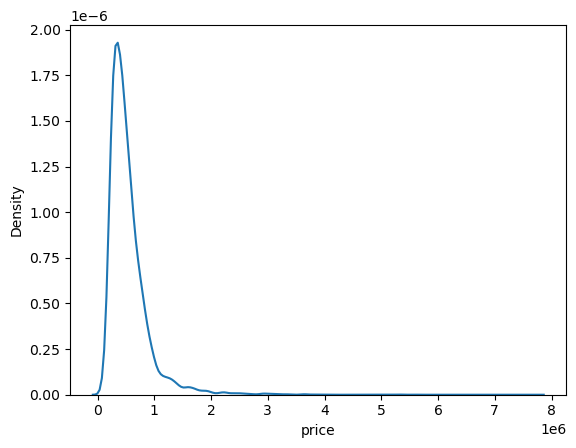

In [11]:
"""
seaborn의 `kdeplot`을 활용해 `y`의 분포를 확인해주세요!
"""

#코드 작성
sns.kdeplot(y)
plt.show()

In [12]:
y = np.log1p(y)
y

0        12.309987
1        12.100718
2        13.142168
3        12.458779
4        12.583999
           ...    
15030    13.322338
15031    13.822984
15032    12.793862
15033    12.899222
15034    12.691584
Name: price, Length: 15035, dtype: float64

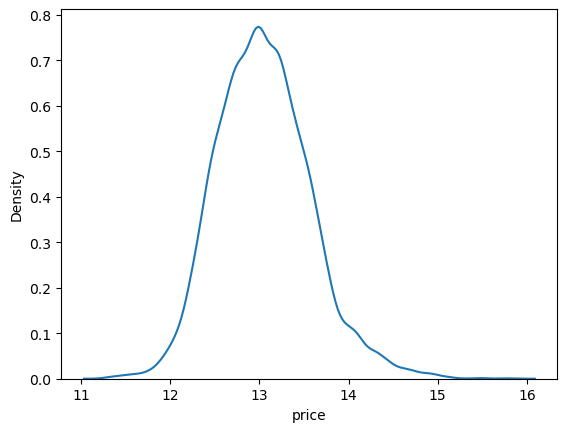

In [13]:
sns.kdeplot(y)
plt.show()

In [14]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15035 entries, 0 to 15034
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           15035 non-null  int64  
 1   bedrooms       15035 non-null  int64  
 2   bathrooms      15035 non-null  float64
 3   sqft_living    15035 non-null  int64  
 4   sqft_lot       15035 non-null  int64  
 5   floors         15035 non-null  float64
 6   waterfront     15035 non-null  int64  
 7   view           15035 non-null  int64  
 8   condition      15035 non-null  int64  
 9   grade          15035 non-null  int64  
 10  sqft_above     15035 non-null  int64  
 11  sqft_basement  15035 non-null  int64  
 12  yr_built       15035 non-null  int64  
 13  yr_renovated   15035 non-null  int64  
 14  zipcode        15035 non-null  int64  
 15  lat            15035 non-null  float64
 16  long           15035 non-null  float64
 17  sqft_living15  15035 non-null  int64  
 18  sqft_l

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

print('얍💢')

얍💢


In [16]:
def rmse(y_test, y_pred):
    return np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(y_pred)))

print('얍💢')

얍💢


In [17]:
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor

print('얍💢')

얍💢


In [18]:
# random_state는 모델초기화나 데이터셋 구성에 사용되는 랜덤 시드값입니다.
#random_state=None    # 이게 초기값입니다. 아무것도 지정하지 않고 None을 넘겨주면 모델 내부에서 임의로 선택합니다.
random_state=2020        # 하지만 우리는 이렇게 고정값을 세팅해 두겠습니다.

gboost = GradientBoostingRegressor(random_state=random_state)
xgboost = XGBRegressor(random_state=random_state)
lightgbm = LGBMRegressor(random_state=random_state)
rdforest = RandomForestRegressor(random_state=random_state)

models = [gboost, xgboost, lightgbm, rdforest]

print('얍💢')

얍💢


In [19]:
gboost.__class__.__name__

'GradientBoostingRegressor'

In [20]:
df = {}

for model in models:
    # 모델 이름 획득
    model_name = model.__class__.__name__

    # train, test 데이터셋 분리
    # random_state를 사용하여 고정하고 train과 test 셋의 비율은 8:2로 합니다.
    X_train, X_test, y_train, y_test = train_test_split(train, y, random_state=random_state, test_size=0.2)


    # 모델 학습
    model.fit(X_train, y_train)

    # 예측
    y_pred = model.predict(X_test)

    # 예측 결과의 rmse값 저장
    df[model_name] = rmse(y_test, y_pred)

    # data frame에 저장
    score_df = pd.DataFrame(df, index=['RMSE']).T.sort_values('RMSE', ascending=False)

df

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000835 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2298
[LightGBM] [Info] Number of data points in the train set: 12028, number of used features: 19
[LightGBM] [Info] Start training from score 13.047779


{'GradientBoostingRegressor': np.float64(128360.19649691365),
 'XGBRegressor': np.float64(117618.22355411823),
 'LGBMRegressor': np.float64(111920.36735892233),
 'RandomForestRegressor': np.float64(125486.94461618949)}

In [21]:
def get_scores(models, train, y):
    df = {}

    for model in models:
        model_name = model.__class__.__name__

        X_train, X_test, y_train, y_test = train_test_split(train, y, random_state=random_state, test_size=0.2)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        df[model_name] = rmse(y_test, y_pred)
        score_df = pd.DataFrame(df, index=['RMSE']).T.sort_values('RMSE', ascending=False)

    return score_df

In [22]:
from sklearn.model_selection import GridSearchCV

print('얍💢')

얍💢


In [23]:
#param_grid 범위를 바꿔가며 튜닝
param_grid = {
    'n_estimators': [600, 700, 800, 900, 1000],
    'max_depth': [10],
    'learning_rate': [0.05]
}

In [24]:
model = LGBMRegressor(random_state=random_state)

print('얍💢')

얍💢


In [25]:
grid_model = GridSearchCV(model, param_grid=param_grid, \
                        scoring='neg_mean_squared_error', \
                        cv=5, verbose=1, n_jobs=5)

_ = grid_model.fit(train, y)

Fitting 5 folds for each of 5 candidates, totalling 25 fits
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001192 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2332
[LightGBM] [Info] Number of data points in the train set: 12028, number of used features: 19
[LightGBM] [Info] Start training from score 13.050660
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGB

In [26]:
grid_model.best_params_

{'learning_rate': 0.05, 'max_depth': 10, 'n_estimators': 600}

In [27]:
grid_model.best_score_

np.float64(-0.02587341710140218)

In [28]:
params = grid_model.cv_results_['params']
score = grid_model.cv_results_['mean_test_score']

results = pd.DataFrame(params)

results['RMSLE'] = np.sqrt(-score)

results.sort_values('RMSLE').head(10)

,learning_rate,max_depth,n_estimators,RMSLE
0,0.05,10,600,0.160852
1,0.05,10,700,0.160877
2,0.05,10,800,0.160946
3,0.05,10,900,0.161010
4,0.05,10,1000,0.161028


In [29]:
grid_model.cv_results_

{'mean_fit_time': array([3.15946932, 3.47809863, 4.33449159, 4.67433367, 4.61115165]),
 'std_fit_time': array([0.1637545 , 0.26358453, 0.34319093, 0.5563967 , 0.38678841]),
 'mean_score_time': array([0.47749891, 0.54088578, 0.60049953, 0.62336574, 0.51818395]),
 'std_score_time': array([0.09702131, 0.08808183, 0.04150575, 0.05624609, 0.1734748 ]),
 'param_learning_rate': masked_array(data=[0.05, 0.05, 0.05, 0.05, 0.05],
              mask=[False, False, False, False, False],
        fill_value=1e+20),
 'param_max_depth': masked_array(data=[10, 10, 10, 10, 10],
              mask=[False, False, False, False, False],
        fill_value=999999),
 'param_n_estimators': masked_array(data=[600, 700, 800, 900, 1000],
              mask=[False, False, False, False, False],
        fill_value=999999),
 'params': [{'learning_rate': 0.05, 'max_depth': 10, 'n_estimators': 600},
  {'learning_rate': 0.05, 'max_depth': 10, 'n_estimators': 700},
  {'learning_rate': 0.05, 'max_depth': 10, 'n_estimators

In [30]:
params = grid_model.cv_results_['params']
params

[{'learning_rate': 0.05, 'max_depth': 10, 'n_estimators': 600},
 {'learning_rate': 0.05, 'max_depth': 10, 'n_estimators': 700},
 {'learning_rate': 0.05, 'max_depth': 10, 'n_estimators': 800},
 {'learning_rate': 0.05, 'max_depth': 10, 'n_estimators': 900},
 {'learning_rate': 0.05, 'max_depth': 10, 'n_estimators': 1000}]

In [31]:
score = grid_model.cv_results_['mean_test_score']
score

array([-0.02587342, -0.02588145, -0.02590368, -0.02592421, -0.02592995])

In [32]:
results = pd.DataFrame(params)
results['score'] = score

results

,learning_rate,max_depth,n_estimators,score
0,0.05,10,600,-0.025873
1,0.05,10,700,-0.025881
2,0.05,10,800,-0.025904
3,0.05,10,900,-0.025924
4,0.05,10,1000,-0.025930


In [33]:
results['RMSE'] = np.sqrt(-1 * results['score'])
results

,learning_rate,max_depth,n_estimators,score,RMSE
0,0.05,10,600,-0.025873,0.160852
1,0.05,10,700,-0.025881,0.160877
2,0.05,10,800,-0.025904,0.160946
3,0.05,10,900,-0.025924,0.161010
4,0.05,10,1000,-0.025930,0.161028


In [34]:
results = results.rename(columns={'RMSE': 'RMSLE'})
results

,learning_rate,max_depth,n_estimators,score,RMSLE
0,0.05,10,600,-0.025873,0.160852
1,0.05,10,700,-0.025881,0.160877
2,0.05,10,800,-0.025904,0.160946
3,0.05,10,900,-0.025924,0.161010
4,0.05,10,1000,-0.025930,0.161028


In [35]:
results = results.sort_values('RMSLE')
results

,learning_rate,max_depth,n_estimators,score,RMSLE
0,0.05,10,600,-0.025873,0.160852
1,0.05,10,700,-0.025881,0.160877
2,0.05,10,800,-0.025904,0.160946
3,0.05,10,900,-0.025924,0.161010
4,0.05,10,1000,-0.025930,0.161028


In [36]:
"""
다음과 같은 과정을 진행할 수 있는 `my_GridSearch(model, train, y, param_grid, verbose=2, n_jobs=5)` 함수를 구현해 보세요.

1. GridSearchCV 모델로 `model`을 초기화합니다.
2. 모델을 fitting 합니다.
3. params, score에 각 조합에 대한 결과를 저장합니다.
4. 데이터 프레임을 생성하고, RMSLE 값을 추가한 후 점수가 높은 순서로 정렬한 `results`를 반환합니다.
"""

def my_GridSearch(model, train, y, param_grid, verbose=2, n_jobs=5):
    # GridSearchCV 모델로 초기화
    grid_model = GridSearchCV(model, param_grid=param_grid, scoring='neg_mean_squared_error', \
                              cv=5, verbose=verbose, n_jobs=n_jobs)

    # 모델 fitting
    grid_model.fit(train, y)

    # 결과값 저장
    params = grid_model.cv_results_['params']
    score = grid_model.cv_results_['mean_test_score']

    # 데이터 프레임 생성
    results = pd.DataFrame(params)
    results['score'] = score

    # RMSLE 값 계산 후 정렬
    results['RMSLE'] = np.sqrt(-1 * results['score'])
    results = results.sort_values('RMSLE')

    return results

In [37]:
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [1, 10],
}

model = LGBMRegressor(random_state=random_state)
my_GridSearch(model, train, y, param_grid, verbose=2, n_jobs=5)

Fitting 5 folds for each of 4 candidates, totalling 20 fits
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001234 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2327
[LightGBM] [Info] Number of data points in the train set: 12028, number of used features: 19
[LightGBM] [Info] Start training from score 13.052839
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGB

,max_depth,n_estimators,score,RMSLE
3,10,100,-0.027027,0.164399
2,10,50,-0.029177,0.170814
1,1,100,-0.055020,0.234564
0,1,50,-0.073394,0.270914


In [38]:
model = LGBMRegressor(max_depth=10, n_estimators=100, random_state=random_state)
model.fit(train, y)
prediction = model.predict(test)
prediction

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001151 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2338
[LightGBM] [Info] Number of data points in the train set: 15035, number of used features: 19
[LightGBM] [Info] Start training from score 13.048122


array([13.13580793, 13.08051399, 14.11202067, ..., 13.01592878,
       12.69894979, 12.96297768], shape=(6468,))

In [39]:
prediction = np.expm1(prediction)
prediction

array([ 506766.66784595,  479506.10405112, 1345155.15609376, ...,
        449515.92243642,  327402.87855805,  426332.71354302],
      shape=(6468,))

In [40]:
data_dir = './data'

submission_path = join(data_dir, 'sample_submission.csv')
submission = pd.read_csv(submission_path)
submission.head()

,id,price
0,15035,100000
1,15036,100000
2,15037,100000
3,15038,100000
4,15039,100000


In [41]:
submission['price'] = prediction
submission.head()

,id,price
0,15035,5.067667e+05
1,15036,4.795061e+05
2,15037,1.345155e+06
3,15038,3.122579e+05
4,15039,3.338645e+05


In [42]:
submission_csv_path = '{}/submission_{}_RMSLE_{}.csv'.format(data_dir, 'lgbm', '0.164399')
submission.to_csv(submission_csv_path, index=False)
print(submission_csv_path)

./data/submission_lgbm_RMSLE_0.164399.csv


In [43]:
"""
아래의 과정을 수행하는 `save_submission(model, train, y, test, model_name, rmsle)` 함수를 구현해 주세요.
1. 모델을 `train`, `y`로 학습시킵니다.
2. `test`에 대해 예측합니다.
3. 예측값을 `np.expm1`으로 변환하고, `submission_model_name_RMSLE_100000.csv` 형태의 `csv` 파일을 저장합니다.
"""

# 코드 작성
def save_submission(model, train, y, test, model_name, rmsle=None):
    model.fit(train, y)
    prediction = model.predict(test)
    prediction = np.expm1(prediction)
    data_dir = './data'
    submission_path = join(data_dir, 'sample_submission.csv')
    submission = pd.read_csv(submission_path)
    submission['price'] = prediction
    submission_csv_path = '{}/submission_{}_RMSLE_{}.csv'.format(data_dir, model_name, rmsle)
    submission.to_csv(submission_csv_path, index=False)
    print('{} saved!'.format(submission_csv_path))

In [44]:
save_submission(model, train, y, test, 'lgbm_tuned', rmsle='0.160852')

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001043 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2338
[LightGBM] [Info] Number of data points in the train set: 15035, number of used features: 19
[LightGBM] [Info] Start training from score 13.048122
./data/submission_lgbm_tuned_RMSLE_0.160852.csv saved!


In [45]:
from xgboost import XGBRegressor

lgbm = LGBMRegressor(
    learning_rate=0.05,
    max_depth=10,
    n_estimators=600,
    random_state=random_state
)

xgb_model = XGBRegressor(
    learning_rate=0.05,
    max_depth=6,
    n_estimators=600,
    random_state=random_state
)

lgbm.fit(train, y)
xgb_model.fit(train, y)

pred_lgbm = lgbm.predict(test)
pred_xgb = xgb_model.predict(test)

pred = pred_lgbm * 0.6 + pred_xgb * 0.4
pred = np.expm1(pred)

submission = pd.read_csv(data_dir + '/sample_submission.csv')
submission['price'] = pred
submission.to_csv(data_dir + '/submission_ensemble_6040.csv', index=False)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000956 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2338
[LightGBM] [Info] Number of data points in the train set: 15035, number of used features: 19
[LightGBM] [Info] Start training from score 13.048122
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


In [46]:
# 1. 데이터 다시 불러오기
train2 = pd.read_csv(data_dir + '/train.csv')
test2 = pd.read_csv(data_dir + '/test.csv')

y2 = train2['price']
y2 = np.log1p(y2)

sub_id = test2['id']

# 2. train/test 합쳐서 같은 전처리
train2 = train2.drop(['price'], axis=1)
data2 = pd.concat([train2, test2], axis=0)

# 3. date 처리
data2['date'] = data2['date'].apply(lambda x: int(str(x)[:6]))
data2['year'] = data2['date'] // 100
data2['month'] = data2['date'] % 100

# 4. id 삭제
data2 = data2.drop(['id'], axis=1)

# 5. 집 나이 관련 특성
data2['house_age'] = data2['year'] - data2['yr_built']
data2['renovated'] = data2['yr_renovated'].apply(lambda x: 0 if x == 0 else 1)
data2['renovated_age'] = data2['year'] - data2['yr_renovated']
data2.loc[data2['yr_renovated'] == 0, 'renovated_age'] = 0

# 6. 면적 관련 특성
data2['total_sqft'] = data2['sqft_living'] + data2['sqft_lot']
data2['sqft_ratio'] = data2['sqft_living'] / (data2['sqft_lot'] + 1)
data2['basement_ratio'] = data2['sqft_basement'] / (data2['sqft_living'] + 1)

# 7. 등급/상태 조합
data2['grade_condition'] = data2['grade'] * data2['condition']
data2['bath_bed'] = data2['bathrooms'] / (data2['bedrooms'] + 1)

# 8. 치우친 컬럼 로그 변환
skew_cols = [
    'sqft_living', 'sqft_lot', 'sqft_above', 'sqft_basement',
    'sqft_living15', 'sqft_lot15', 'total_sqft'
]

for col in skew_cols:
    data2[col] = np.log1p(data2[col])

# 9. 다시 train/test 분리
train_len = len(train2)
X2 = data2.iloc[:train_len, :]
test_final = data2.iloc[train_len:, :]

# 10. 최종 모델
final_model = LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=10,
    num_leaves=40,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1,
    random_state=random_state
)

final_model.fit(X2, y2)

pred = final_model.predict(test_final)
pred = np.expm1(pred)

submission = pd.read_csv(data_dir + '/sample_submission.csv')
submission['price'] = pred
submission.to_csv(data_dir + '/submission_final_feature_lgbm.csv', index=False)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001336 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3386
[LightGBM] [Info] Number of data points in the train set: 15035, number of used features: 29
[LightGBM] [Info] Start training from score 13.048122
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

In [47]:
train3 = pd.read_csv(data_dir + '/train.csv')
test3 = pd.read_csv(data_dir + '/test.csv')

y3 = np.log1p(train3['price'])

train3 = train3.drop(['price'], axis=1)
data3 = pd.concat([train3, test3], axis=0)

data3['date'] = data3['date'].apply(lambda x: int(str(x)[:6]))
data3['year'] = data3['date'] // 100
data3['month'] = data3['date'] % 100

data3['house_age'] = data3['year'] - data3['yr_built']
data3['renovated'] = data3['yr_renovated'].apply(lambda x: 0 if x == 0 else 1)

data3['total_sqft'] = data3['sqft_living'] + data3['sqft_lot']
data3['sqft_ratio'] = data3['sqft_living'] / (data3['sqft_lot'] + 1)
data3['grade_condition'] = data3['grade'] * data3['condition']
data3['bath_bed'] = data3['bathrooms'] / (data3['bedrooms'] + 1)

# 위치는 숫자 순서 의미가 없어서 원-핫 인코딩
data3['zipcode'] = data3['zipcode'].astype(str)
data3 = pd.get_dummies(data3, columns=['zipcode'])

data3 = data3.drop(['id'], axis=1)

skew_cols = [
    'sqft_living', 'sqft_lot', 'sqft_above', 'sqft_basement',
    'sqft_living15', 'sqft_lot15', 'total_sqft'
]

for col in skew_cols:
    data3[col] = np.log1p(data3[col])

train_len = len(train3)
X3 = data3.iloc[:train_len, :]
test3_final = data3.iloc[train_len:, :]

model1 = LGBMRegressor(
    n_estimators=900,
    learning_rate=0.03,
    max_depth=10,
    num_leaves=40,
    min_child_samples=20,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1,
    random_state=random_state
)

model2 = XGBRegressor(
    n_estimators=700,
    learning_rate=0.03,
    max_depth=5,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=random_state
)

model1.fit(X3, y3)
model2.fit(X3, y3)

pred1 = model1.predict(test3_final)
pred2 = model2.predict(test3_final)

pred = pred1 * 0.75 + pred2 * 0.25
pred = np.expm1(pred)

submission = pd.read_csv(data_dir + '/sample_submission.csv')
submission['price'] = pred
submission.to_csv(data_dir + '/submission_last_zipcode_ensemble.csv', index=False)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001555 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3145
[LightGBM] [Info] Number of data points in the train set: 15035, number of used features: 96
[LightGBM] [Info] Start training from score 13.048122
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

In [48]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=3000,
    learning_rate=0.02,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=random_state
)

xgb_model.fit(X3, y3)

pred = xgb_model.predict(test3_final)
pred = np.expm1(pred)

submission = pd.read_csv(data_dir + '/sample_submission.csv')
submission['price'] = pred

submission.to_csv(
    data_dir + '/submission_xgb_only.csv',
    index=False
)

In [49]:
# final_feature_lgbm 예측 다시 만들기
pred_lgbm = final_model.predict(test_final)

# xgb_only 예측 다시 만들기
pred_xgb = xgb_model.predict(test3_final)

# 둘 다 로그 예측값이므로 로그 상태에서 평균
pred = pred_lgbm * 0.5 + pred_xgb * 0.5

pred = np.expm1(pred)

submission = pd.read_csv(data_dir + '/sample_submission.csv')
submission['price'] = pred

submission.to_csv(
    data_dir + '/submission_final_5050.csv',
    index=False
)

In [50]:
sub_lgbm = pd.read_csv(data_dir + '/submission_final_feature_lgbm.csv')
sub_xgb = pd.read_csv(data_dir + '/submission_xgb_only.csv')

submission = pd.read_csv(data_dir + '/sample_submission.csv')

submission['price'] = (
    sub_lgbm['price'] * 0.7 +
    sub_xgb['price'] * 0.3
)

submission.to_csv(data_dir + '/submission_final_blend_7030.csv', index=False)

In [51]:
sub_lgbm = pd.read_csv(data_dir + '/submission_final_feature_lgbm.csv')
sub_xgb = pd.read_csv(data_dir + '/submission_xgb_only.csv')

submission = pd.read_csv(data_dir + '/sample_submission.csv')

submission['price'] = (
    sub_lgbm['price'] * 0.8 +
    sub_xgb['price'] * 0.2
)

submission.to_csv(
    data_dir + '/submission_final_blend_8020.csv',
    index=False
)

In [52]:
sub_lgbm = pd.read_csv(data_dir + '/submission_final_feature_lgbm.csv')
sub_xgb = pd.read_csv(data_dir + '/submission_xgb_only.csv')

submission = pd.read_csv(data_dir + '/sample_submission.csv')

submission['price'] = (
    sub_lgbm['price'] * 0.6 +
    sub_xgb['price'] * 0.4
)

submission.to_csv(
    data_dir + '/submission_final_blend_6040_v2.csv',
    index=False
)

In [59]:
sub_lgbm = pd.read_csv(data_dir + '/submission_final_feature_lgbm.csv')
sub_xgb = pd.read_csv(data_dir + '/submission_xgb_only.csv')

submission = pd.read_csv(data_dir + '/sample_submission.csv')

submission['price'] = (
    sub_lgbm['price'] * 0.50 +
    sub_xgb['price'] * 0.50
)


submission.to_csv(
    data_dir + '/submission_final_blend_5050.csv',
    index=False
)

In [64]:
!pip install catboost
# CatBoost 라이브러리에서 회귀 모델을 가져오기.
# CatBoost는 LightGBM, XGBoost처럼 성능이 좋은 부스팅 계열 모델
from catboost import CatBoostRegressor

# CatBoost 회귀 모델 생성
cat_model = CatBoostRegressor(
    iterations=3000,        # 트리를 3000번 만들면서 학습. n_estimators와 비슷한 역할
    learning_rate=0.03,     # 한 번 학습할 때 얼마나 크게 업데이트할지 정하기. 작을수록 천천히 안정적으로 학습
    depth=6,                # 트리의 깊이. 너무 깊으면 과적합될 수 있어서 6 정도로 설정
    loss_function='RMSE',   # 회귀 문제이므로 RMSE 기준으로 오차를 줄이도록 학습
    verbose=0,              # 학습 과정 출력 생략. 100으로 바꾸면 중간 학습 로그가 출력
    random_state=random_state # 실행할 때마다 결과가 달라지지 않도록 랜덤값을 고정
)

# 모델 학습
# X3 : 전처리와 feature engineering이 적용된 학습 데이터
# y3 : log1p로 변환된 집값 정답 데이터
cat_model.fit(X3, y3)

# 테스트 데이터에 대해 집값 예측
# test3_final : train과 같은 방식으로 전처리된 테스트 데이터
pred_cat = cat_model.predict(test3_final)

# 모델은 log 변환된 집값을 예측했으므로,
# np.expm1()을 사용해 원래 집값 단위로 되돌리기
pred_cat = np.expm1(pred_cat)

# 캐글 제출 양식 파일을 불러오기
submission = pd.read_csv(data_dir + '/sample_submission.csv')

# 제출 양식의 price 컬럼에 예측한 집값을 넣기.
submission['price'] = pred_cat

# 최종 제출 파일 저장
# index=False를 해야 불필요한 인덱스 열이 생기지 않음
submission.to_csv(
    data_dir + '/submission_catboost.csv',
    index=False
)

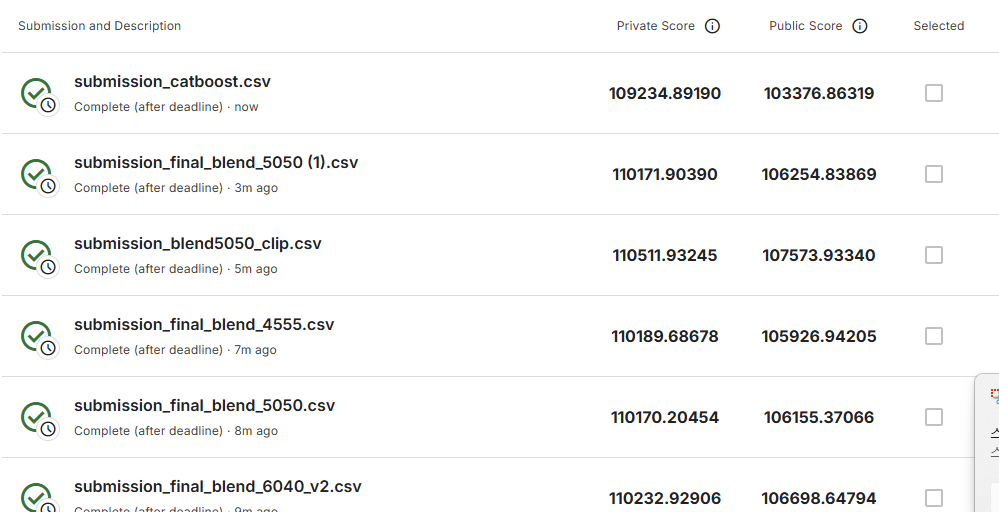

# 디버깅

이번 프로젝트를 진행하면서 여러 오류와 시행착오가 있었다.
먼저 GridSearchCV 실행 후 estimator.js 파일을 찾을 수 없다는 FileNotFoundError가 발생했다. 이는 모델 학습 자체의 오류가 아니라, 주피터 노트북에서 모델 객체를 HTML 형태로 출력하려고 하면서 발생한 문제였다.
그래서 grid_model.fit(train, y) 대신 _ = grid_model.fit(train, y) 형태로 작성하여 객체 출력을 막아 해결했다.

모델 예측 과정에서는 LightGBM 모델이 학습할 때 사용한 feature 개수와 예측할 때 사용한 feature 개수가 달라 오류가 발생했다. 이는 서로 다른 전처리 데이터를 사용했기 때문이었다. 이후 학습 데이터와 테스트 데이터가 같은 컬럼 구조를 갖도록 전처리 과정을 통일하였다.

# 회고

이번 프로젝트를 통해 캐글 대회는 단순히 모델을 실행하는 것에서 끝나는 것이 아니라, 데이터 전처리, 하이퍼파라미터 튜닝, feature engineering, 앙상블까지 여러 실험을 반복하는 과정이라는 것을 알게 되었다.

처음에는 LightGBM의 n_estimators, max_depth, learning_rate를 조정하며 성능을 개선하려고 했다. 하지만 튜닝 결과가 항상 캐글 점수 향상으로 이어지지는 않았다. 검증 점수는 좋아졌지만 실제 Private Score는 나빠지는 경우도 있었고, 이를 통해 과적합과 검증 데이터의 한계를 체감할 수 있었다.

이후 집의 나이, 리모델링 여부, 면적 비율, 등급과 상태의 조합 등 새로운 feature를 추가하면서 점수가 개선되었다. 또한 LightGBM과 XGBoost 예측값을 섞는 앙상블을 적용하면서 Private Score를 크게 낮출 수 있었다. 마지막으로 CatBoost 모델까지 추가하면서 기존 모델과 다른 방식의 예측을 시도했고, 다양한 모델을 비교하는 경험을 할 수 있었다.

이번 과정을 통해 모델 성능을 높이기 위해서는 단순히 좋은 모델 하나를 사용하는 것보다, 데이터의 의미를 이해하고 여러 모델의 예측을 실험적으로 조합하는 것이 중요하다는 것을 배웠다.